# Numerical Methods for Root Finding #

$Author$: Michael Simons

$Class$: MTH 437 - Numerical Analysis

$Date$: 09/18/23

## Introduction ##

The following exploration will consider three numerical methods for approximating the roots of functions. Applications of each method will be demonstrated to showcase their strengths, and one case will expose the impact of ill-conditioned problems in numerical computation.

## Bisection Method ##

The Bisection method is a simple yet robust numerical technique used for approximating the root of a function. The method is applicable when there exist two known values $a$ and $b$ such that a function $f$ has opposite signs at points $f(a)$ and $f(b)$. This condition ensures that at least one root of $f$ exists within interval $[a,b]$. The objective of the Bisection Method is to iteratively reduce the interval, increasing the precision of the root approximation. This section will aim to provide a demonstration of the method through its implementation followed by an application to a test function with a known root.

The method will be implemented using a function that takes five required parameters: 

- The function $f$ for which we want to find the root

- A known root for the function

- a and b, which define the interval $[a, b]$ where the root is expected

- n_iterations (the maximum number of iterations to perform).

Additionally, we have a parameter epsilon which defines the desired precision for the root approximation, and an iteration parameter to keep track of the current iteration. In this demonstration, a tolerance $ε = 10^{-6}$ will be selected.

In [1]:
# Approximates the root the given function within a specified interval [a, b]
def bisection(func,known_root,a,b,n_iterations,epsilon=1e-6,iteration=1):
    if iteration <= n_iterations:
        mid = (a+b)/2  #calculate the midpoint of the current interval 
        relative_error = abs(mid - known_root) / abs(known_root) #compute relative error
        print(f'Iteration: {iteration}, Approximation: {mid}, Relative Error: {relative_error}') #display table row
        if abs(func(mid)) <= epsilon: return mid #value at the midpoint is within the desired precision
        elif func(a)*func(mid) < 0: #test for which half of the interval the root lies in
            return bisection(func,known_root,a,mid,n_iterations,epsilon,iteration+1) #the root lies in the left half of the interval
    else: # n_iterations are complete
        print('Not enough iterations for desired accuracy') #failed to compute precise approximation
        return
    return bisection(func,known_root,mid,b,n_iterations,epsilon,iteration+1) #the root lies in the right half of the interval

With the Bisection method implemented, a test will now be conducted on a function with a known root:



Consider $f(x) = x^{3}+2x^{2}-4x-8$, with roots $x=2$ and $x=-2$. For this demonstration, the root $x=2$ will be computed. First we will define the function and confirm the known root.

In [2]:
def f(x): return x**3+2*x**2-4*x-8 #define function f
print(f'f(2) = {f(2)}')

f(2) = 0


To apply the Bisection method, we must find values a and b such that $[a,b]$ contains the known root with $f(a)$ and $f(b)$ having opposite signs.

In [3]:
print(f'f(0) = {f(0)}\nf(12) = {f(12)}') #confirm values for a,b

f(0) = -8
f(12) = 1960


Observably, $f(0)$ and $f(12)$ produce values of opposite signs and an interval which contains the known root $x=2$. Therefore the method may begin with $a=0$ and $b=12$.

In [4]:
bisection(f,2, 0, 12, 30) #begin bisection method of f on the interval [0,12], 30 max iterations.

Iteration: 1, Approximation: 6.0, Relative Error: 2.0
Iteration: 2, Approximation: 3.0, Relative Error: 0.5
Iteration: 3, Approximation: 1.5, Relative Error: 0.25
Iteration: 4, Approximation: 2.25, Relative Error: 0.125
Iteration: 5, Approximation: 1.875, Relative Error: 0.0625
Iteration: 6, Approximation: 2.0625, Relative Error: 0.03125
Iteration: 7, Approximation: 1.96875, Relative Error: 0.015625
Iteration: 8, Approximation: 2.015625, Relative Error: 0.0078125
Iteration: 9, Approximation: 1.9921875, Relative Error: 0.00390625
Iteration: 10, Approximation: 2.00390625, Relative Error: 0.001953125
Iteration: 11, Approximation: 1.998046875, Relative Error: 0.0009765625
Iteration: 12, Approximation: 2.0009765625, Relative Error: 0.00048828125
Iteration: 13, Approximation: 1.99951171875, Relative Error: 0.000244140625
Iteration: 14, Approximation: 2.000244140625, Relative Error: 0.0001220703125
Iteration: 15, Approximation: 1.9998779296875, Relative Error: 6.103515625e-05
Iteration: 16, A

2.0000000596046448

The Bisection method was successfully applied to approximate the root of $f(x)=x^{3}+2x^{2}-4x-8$. Beginning with the initial interval $[0,12]$, the method iteratively decreased the interval and provided an approximation of a root $x = 2.0000000596046448$ which lies within the desired tolerance $ε=10^{−6}$, as the known root is $x = 2$.

## Newton's Method ##

Newton's method is another numerical technique used to approximate the root of a function. Unlike the previously demonstrated Bisection method, Newton's method relies on the derivative of the function to improve approximation precision at each iteration. Another important distinction is that rather than an interval, Newton's method requires a singular initial guess relatively close to the root.

This section will aim to implement Newton's method and find the root of the function $f(x)=x^{3}-6$. Firstly, the Bisection method will be utilized to find an initial approximation within a tolerance $ε=10^{-2}$. Newton's method will then be employed to compute a more precise approximation within a tolerance $ε=10^{-12}$.

In [5]:
def f(x): return x**3-6 #re-define f
print(f'f(1) = {f(1)}\nf(2) = {f(2)}') #confirm values for a,b

f(1) = -5
f(2) = 2


$f(1)$ and $f(2)$ produce values of opposite sign, therefore the Bisection method may begin with interval $[1,2]$.

In [6]:
bisection(f,6**(1/3),-5,2,10,epsilon=10e-2) #compute initial approximation starting with interval [-5,2]

Iteration: 1, Approximation: -1.5, Relative Error: 1.8254818122236567
Iteration: 2, Approximation: 0.25, Relative Error: 0.8624196979627239
Iteration: 3, Approximation: 1.125, Relative Error: 0.3808886408322575
Iteration: 4, Approximation: 1.5625, Relative Error: 0.1401231122670243
Iteration: 5, Approximation: 1.78125, Relative Error: 0.01974034798440771
Iteration: 6, Approximation: 1.890625, Relative Error: 0.04045103415690059
Iteration: 7, Approximation: 1.8359375, Relative Error: 0.01035534308624644
Iteration: 8, Approximation: 1.80859375, Relative Error: 0.004692502449080634


1.80859375

With an initial approximation of $1.80859375$, Newton's method can now be implemented and utilized to provide a more precise approximation of $f$'s root. The method will be encapsulated by a function which requires four parameters:

- The function $f$ for which we want to find the root

- The derivative of $f$

- Initial approximation

- Error tolerance

As previously stated, the tolerance $ε=10^{−12}$ will be selected.

In [7]:
#Approximates the root of a function by iteratively applying its derivative
def newtons_method(func,func_derivative,initial_approximation,tolerance=1e-12):
    xn = initial_approximation #assign first value
    practical_error = float('inf') #assign error variable
    iteration = 1 #iteration counter
    while practical_error > tolerance: #check error tolerance
        xn1 = xn-func(xn)/func_derivative(xn) #compute xn+1
        practical_error = abs(xn1-xn)/abs(xn) #compute practical error
        print(f'Iteration: {iteration}, Approximation: {xn1}, Practical Error: {practical_error}')
        xn = xn1 #update current value
        iteration += 1 #increment iteration counter
    return xn #return sufficient approximation

In [8]:
def df_by_dx(x): return 3*x**2 #derivative of f
newtons_method(f,df_by_dx,1.80859375)

Iteration: 1, Approximation: 1.8171608568830693, Practical Error: 0.004736888470984308
Iteration: 2, Approximation: 1.8171205937242907, Practical Error: 2.2157179220582932e-05
Iteration: 3, Approximation: 1.8171205928321397, Practical Error: 4.909696267864784e-10
Iteration: 4, Approximation: 1.8171205928321397, Practical Error: 0.0


1.8171205928321397

Newton's method was successfully applied with a tolerance $ε=10^{−12}$ using the initial approximation from the Bisection method. As a result, a higher precision approximation of the root of $f(x)$ was computed to be $x = 1.8171205928321397$.

## Fixed Point Iteration ##

Fixed point iteration is a third numerical method used to find the root of a function $f(x)$, in which an equation representing the root of a function is expressed in an equivalent form. In particular, the goal is to find a function $g(x)$ where $g(x)=x$, since solving this equation is the same as finding the root of the original function $f$. To demonstrate the method, this section will aim to derive and implement a convergent fixed-point iteration method to solve the equation $x^{3}-6 = 0$.

Rearranging the equation, 

$x^{3}=6$. 

$x=\sqrt[3]{6}$ 

Therefore $g(x)=\sqrt[3]{6}$ can be used as the fixed iteration function, which will iteratively improve the root approximation.

In [9]:
def g(x): return 6**(1/3) #define function g

The fixed point method will now be implemented as a function which takes three parameters:

- g, the fixed point iteration function

- Initial approximation

- Error tolerance

In this demonstration, a tolerance $ε=10^{−6}$ will be selected.

In [10]:
def fixed_point_iteration(func, initial_approximation, tolerance=10e-6):
    xn = initial_approximation #assign first xn
    practical_error = float('inf') #assign error variable
    iteration = 1 #iteration counter
    while practical_error > tolerance: #check error tolerance
        xn1 = func(xn) #compute xn+1
        practical_error = abs(xn1-xn)/abs(xn) #compute practical error
        print(f'Iteration: {iteration}, Approximation: {xn1}, Practical Error: {practical_error}') #display table row
        xn = xn1 #update current value
        iteration += 1 #increment iteration counter
    return xn #return sufficient approximation

With the fixed point method implemented, it will now be applied to the previously derived function $g(x)$.

In [11]:
fixed_point_iteration(g,55)

Iteration: 1, Approximation: 1.8171205928321397, Practical Error: 0.9669614437666884
Iteration: 2, Approximation: 1.8171205928321397, Practical Error: 0.0


1.8171205928321397

The derived function was successfully applied to the implementation to solve the equation $x^{3}-6=0$, converging to a precise root approximation of $x=1.8171205928321397$. This demonstrates the effectiveness of the fixed-point iteration method in iteratively approximating the roots of equation

## Challenge of ill-conditioned problems ##

This section will demonstrate potential issue of ill-conditioned problems. The Bisection method will be utilized to find the root (near 7) of the following function:

$P(x) = (x-1)(x-2)(x-3)(x-4)(x-5)(x-6)(x-7)-10^{-7}x^7$

In [12]:
def p(x):return (x-1)*(x-2)*(x-3)*(x-4)*(x-5)*(x-6)*(x-7)-10e-7*x**(7)
print(f'p(6)={p(6)}\np(8)={p(8)}')

p(6)=-0.27993599999999996
p(8)=5037.902848


$p(6)$ and $p(8)$ produce values of opposite sign, therefore the Bisection method may begin with interval $[6,8]$. The selected tolerance for this example will be $ε=10^{-8}$.

In [13]:
bisection(p,7.00011,6,8,100,epsilon=10e-8) #Note that 'known value' parameter is not accurate, causing slight error perturbation

Iteration: 1, Approximation: 7.0, Relative Error: 1.5714038779430116e-05
Iteration: 2, Approximation: 7.5, Relative Error: 0.07141173495845062
Iteration: 3, Approximation: 7.25, Relative Error: 0.03569801045983559
Iteration: 4, Approximation: 7.125, Relative Error: 0.01784114821052808
Iteration: 5, Approximation: 7.0625, Relative Error: 0.008912717085874326
Iteration: 6, Approximation: 7.03125, Relative Error: 0.004448501523547447
Iteration: 7, Approximation: 7.015625, Relative Error: 0.0022163937423840085
Iteration: 8, Approximation: 7.0078125, Relative Error: 0.0011003398518022892
Iteration: 9, Approximation: 7.00390625, Relative Error: 0.0005423129065114296
Iteration: 10, Approximation: 7.001953125, Relative Error: 0.00026329943386599976
Iteration: 11, Approximation: 7.0009765625, Relative Error: 0.0001237926975432848
Iteration: 12, Approximation: 7.00146484375, Relative Error: 0.00019354606570464228
Iteration: 13, Approximation: 7.001220703125, Relative Error: 0.0001586693816239635

7.001141918357462

After 32 iterations, the method produced a root approximation $x=7.001141918357462$. The high level of iterations required emphasizes the sensitivity of initial conditions as an effect of ill-conditioned problems in computation.

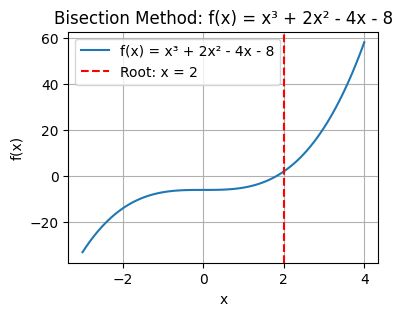

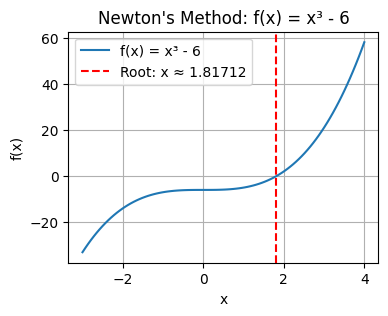

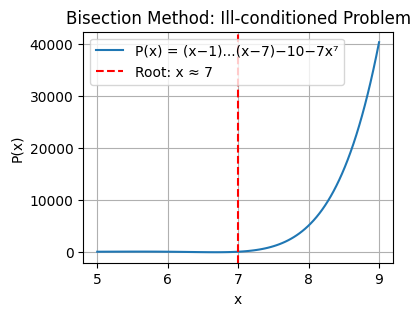

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Define x values for plotting
x = np.linspace(-3, 4, 100)

# Plot f(x) = x³ + 2x² - 4x - 8 
plt.figure(figsize=(4, 3))
plt.plot(x, f(x), label='f(x) = x³ + 2x² - 4x - 8')
plt.title('Bisection Method: f(x) = x³ + 2x² - 4x - 8')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)

# Plot the root found by the Bisection Method 
plt.axvline(x=2, color='red', linestyle='--', label='Root: x = 2')
plt.legend()
plt.show()

# Plot f(x) = x³ - 6
plt.figure(figsize=(4, 3))
plt.plot(x, f(x), label='f(x) = x³ - 6')
plt.title('Newton\'s Method: f(x) = x³ - 6')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)

# Plot the root found by Newton's Method 
plt.axvline(x=1.81712, color='red', linestyle='--', label='Root: x ≈ 1.81712')
plt.legend()
plt.show()

# Plot P(x) = (x−1)(x−2)(x−3)(x−4)(x−5)(x−6)(x−7)−10−7x⁷
x = np.linspace(5, 9, 100)
plt.figure(figsize=(4, 3))
plt.plot(x, p(x), label='P(x) = (x−1)...(x−7)−10−7x⁷')
plt.title('Bisection Method: Ill-conditioned Problem')
plt.xlabel('x')
plt.ylabel('P(x)')
plt.grid(True)

# Plot the root found by the Bisection Method 
plt.axvline(x=7, color='red', linestyle='--', label='Root: x ≈ 7')
plt.legend()
plt.show()

## Conclusion ##

We have explored three numerical methods for approximating the roots of functions. Each method has strengths and limitations, making them suitable for different problems. The challenge of ill-conditioned problems was also encountered, where the method required 32 iterations to converge to an approximation, highlighting the importance of initial conditions in such problems.